# CIFAR-10 Image Classification – Full ML Lifecycle

This notebook covers the complete offline development cycle for a CIFAR-10 classifier that is later served by the Flask API and UI in this repository.

**Sections**
1. Data acquisition
2. Exploratory analysis & preprocessing
3. Model experiments (baseline → enhanced with regularization)
4. Evaluation (≥4 metrics)
5. Saving the best model + generating artifacts used by the API
6. Retraining demonstration with safety gate

## 1. Data Acquisition

CIFAR-10 is loaded directly from `tensorflow.keras.datasets`. It contains 50 000 training and 10 000 test colour images (32×32×3) belonging to 10 mutually exclusive classes.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow {tf.__version__}")

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

(X_train_full, y_train_full), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()
print(f"Train: {X_train_full.shape}, Test: {X_test_raw.shape}")
print(f"Labels shape: {y_train_full.shape}")

TensorFlow 2.21.0
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Labels shape: (50000, 1)


## 2. Exploratory Analysis & Preprocessing

### 2.1 Class balance
CIFAR-10 is perfectly balanced (5 000 images per class in the training set). This is a favourable property – no class-weighting is required.

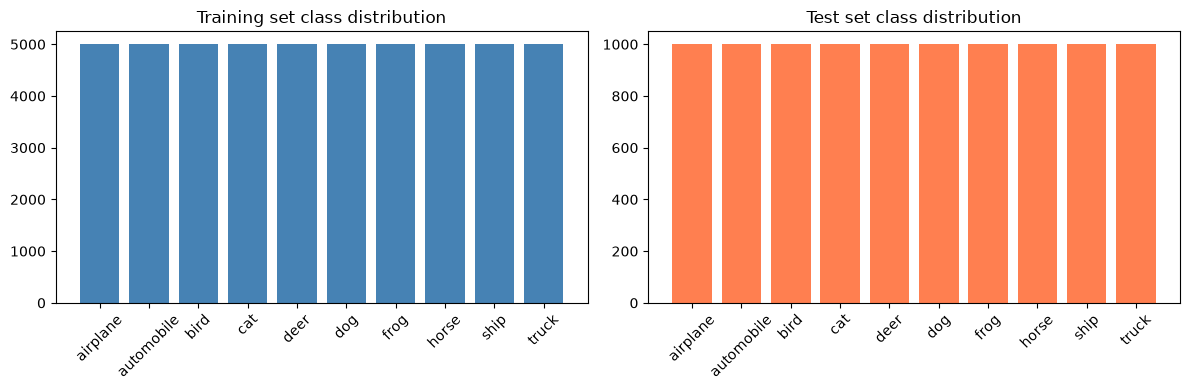

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(CLASS_NAMES, np.bincount(y_train_full.ravel()), color="steelblue")
ax[0].set_title("Training set class distribution")
ax[0].tick_params(axis="x", rotation=45)
ax[1].bar(CLASS_NAMES, np.bincount(y_test_raw.ravel()), color="coral")
ax[1].set_title("Test set class distribution")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 2.2 Sample images

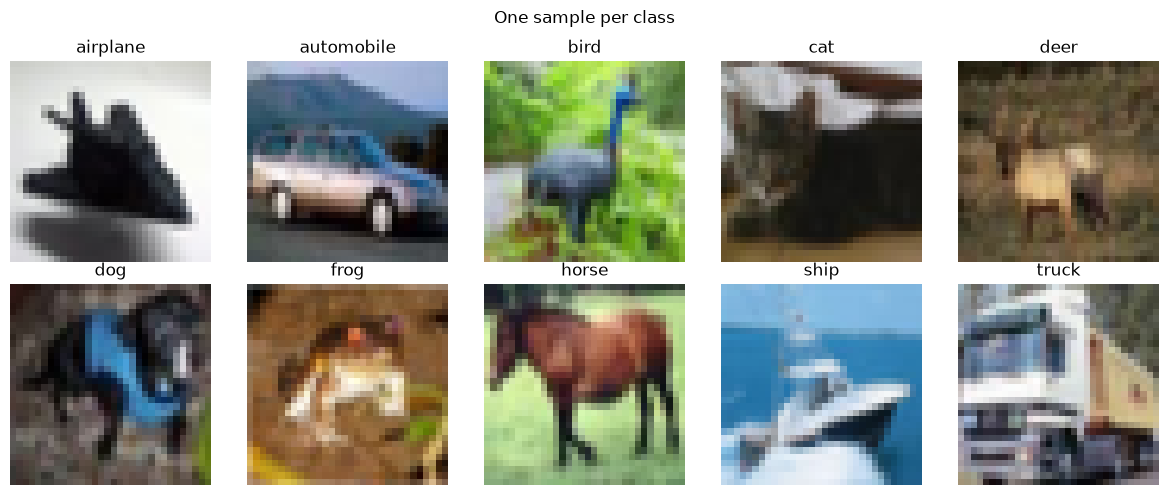

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train_full.ravel() == i)[0][0]
    ax.imshow(X_train_full[idx])
    ax.set_title(CLASS_NAMES[i])
    ax.axis("off")
plt.suptitle("One sample per class")
plt.tight_layout()
plt.show()

### 2.3 Preprocessing

- Pixel values scaled to [0, 1]
- Labels one-hot encoded
- 10 % of training data held out as a validation set for early stopping

In [4]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

y_train_full_oh = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test_raw, 10)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_oh, test_size=0.1, random_state=42, stratify=y_train_full
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


### 2.4 Persist raw arrays for the API

The API’s retraining safety gate and the evaluation script load these `.npy` files.

In [5]:
DATA_DIR = os.path.join("..", "data")
os.makedirs(os.path.join(DATA_DIR, "train"), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, "test"), exist_ok=True)

# Save the original uint8 versions (API will re-normalize)
(X_tr_raw, y_tr_raw), (X_te_raw, y_te_raw) = keras.datasets.cifar10.load_data()
np.save(os.path.join(DATA_DIR, "train", "X_train.npy"), X_tr_raw)
np.save(os.path.join(DATA_DIR, "train", "y_train.npy"), y_tr_raw)
np.save(os.path.join(DATA_DIR, "test", "X_test.npy"), X_te_raw)
np.save(os.path.join(DATA_DIR, "test", "y_test.npy"), y_te_raw)
print("Saved train/test .npy files for the API.")

Saved train/test .npy files for the API.


## 3. Model Experiments

We compare three architectures. All use the Adam optimizer and categorical cross-entropy. EarlyStopping + ReduceLROnPlateau are applied to every run.

In [6]:
def get_callbacks():
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]

def evaluate_model(model, X, y_oh, y_int):
    loss, acc = model.evaluate(X, y_oh, verbose=0)
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    return {
        "loss": float(loss),
        "accuracy": float(acc),
        "precision": float(precision_score(y_int, y_pred, average="macro")),
        "recall": float(recall_score(y_int, y_pred, average="macro")),
        "f1": float(f1_score(y_int, y_pred, average="macro")),
        "y_pred": y_pred,
    }

### Experiment 1 – Baseline CNN (no regularization)

In [7]:
def build_baseline():
    m = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="baseline_cnn")
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

baseline = build_baseline()
hist_base = baseline.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=12, batch_size=64, callbacks=get_callbacks(), verbose=2
)
metrics_base = evaluate_model(baseline, X_test, y_test, y_test_raw.ravel())
print({k: v for k, v in metrics_base.items() if k != "y_pred"})


Epoch 1/12
704/704 - 52s - 75ms/step - accuracy: 0.4402 - loss: 1.5585 - val_accuracy: 0.5402 - val_loss: 1.2724 - learning_rate: 0.0010
Epoch 2/12
704/704 - 78s - 110ms/step - accuracy: 0.5800 - loss: 1.1973 - val_accuracy: 0.6042 - val_loss: 1.1201 - learning_rate: 0.0010
Epoch 3/12
704/704 - 45s - 64ms/step - accuracy: 0.6361 - loss: 1.0381 - val_accuracy: 0.6390 - val_loss: 1.0399 - learning_rate: 0.0010
Epoch 4/12
704/704 - 80s - 113ms/step - accuracy: 0.6705 - loss: 0.9464 - val_accuracy: 0.6728 - val_loss: 0.9444 - learning_rate: 0.0010
Epoch 5/12
704/704 - 44s - 62ms/step - accuracy: 0.6986 - loss: 0.8714 - val_accuracy: 0.6880 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 6/12
704/704 - 83s - 118ms/step - accuracy: 0.7222 - loss: 0.8057 - val_accuracy: 0.6892 - val_loss: 0.8903 - learning_rate: 0.0010
Epoch 7/12
704/704 - 44s - 62ms/step - accuracy: 0.7390 - loss: 0.7526 - val_accuracy: 0.6854 - val_loss: 0.9101 - learning_rate: 0.0010
Epoch 8/12
704/704 - 44s - 62ms/step -

### Experiment 2 – Enhanced CNN (BatchNorm + Dropout)  ← selected

In [ ]:
def build_enhanced():
    m = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ], name="enhanced_cnn")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return m

enhanced = build_enhanced()
hist_enh = enhanced.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=20, batch_size=64, callbacks=get_callbacks(), verbose=2
)
metrics_enh = evaluate_model(enhanced, X_test, y_test, y_test_raw.ravel())
print({k: v for k, v in metrics_enh.items() if k != "y_pred"})


Epoch 1/20
704/704 - 367s - 522ms/step - accuracy: 0.4240 - loss: 1.6909 - val_accuracy: 0.5130 - val_loss: 1.3170 - learning_rate: 0.0010
Epoch 2/20
704/704 - 346s - 492ms/step - accuracy: 0.6082 - loss: 1.1003 - val_accuracy: 0.4304 - val_loss: 2.0052 - learning_rate: 0.0010
Epoch 3/20
704/704 - 340s - 482ms/step - accuracy: 0.6778 - loss: 0.9132 - val_accuracy: 0.5324 - val_loss: 1.4055 - learning_rate: 0.0010
Epoch 4/20
704/704 - 350s - 498ms/step - accuracy: 0.7251 - loss: 0.7943 - val_accuracy: 0.7558 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 5/20
704/704 - 352s - 499ms/step - accuracy: 0.7533 - loss: 0.7113 - val_accuracy: 0.7694 - val_loss: 0.6794 - learning_rate: 0.0010
Epoch 6/20
704/704 - 378s - 537ms/step - accuracy: 0.7750 - loss: 0.6479 - val_accuracy: 0.7814 - val_loss: 0.6481 - learning_rate: 0.0010
Epoch 7/20


### Experiment 3 – Enhanced + Data Augmentation

In [ ]:
def build_enhanced_with_aug():
    """Same enhanced CNN, with Keras preprocessing layers for on-the-fly augmentation.
    Augmentation runs only during training (not at inference).
    """
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomRotation(0.1),
    ], name="augmentation")

    m = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ], name="enhanced_cnn_aug")

    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m

enhanced_aug = build_enhanced_with_aug()
hist_aug = enhanced_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=2,
)
metrics_aug = evaluate_model(enhanced_aug, X_test, y_test, y_test_raw.ravel())
print({k: v for k, v in metrics_aug.items() if k != "y_pred"})

## 4. Model Comparison & Selection

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Baseline": {k: metrics_base[k] for k in ["accuracy", "precision", "recall", "f1", "loss"]},
    "Enhanced": {k: metrics_enh[k] for k in ["accuracy", "precision", "recall", "f1", "loss"]},
    "Enhanced+Aug": {k: metrics_aug[k] for k in ["accuracy", "precision", "recall", "f1", "loss"]},
}).T
print(comparison.round(4))

# Select the model with highest macro-F1
best_name = comparison["f1"].idxmax()
print(f"\nSelected model: {best_name}")
best_model = {"Baseline": baseline, "Enhanced": enhanced, "Enhanced+Aug": enhanced_aug}[best_name]
best_metrics = {"Baseline": metrics_base, "Enhanced": metrics_enh, "Enhanced+Aug": metrics_aug}[best_name]

### Confusion matrix & per-class report for the selected model

In [ ]:
cm = confusion_matrix(y_test_raw.ravel(), best_metrics["y_pred"])
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix – {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test_raw.ravel(), best_metrics["y_pred"], target_names=CLASS_NAMES))

## 5. Persist the selected model & evaluation artefacts

In [ ]:
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

h5_path = os.path.join(MODELS_DIR, "cifar10_classifier.h5")
best_model.save(h5_path)
print(f"Saved {h5_path}")

# Also export SavedModel for reliable ONNX conversion later
savedmodel_path = os.path.join(MODELS_DIR, "cifar10_classifier_savedmodel")
best_model.export(savedmodel_path)
print(f"Exported SavedModel to {savedmodel_path}")

In [ ]:
# Generate eval_metrics.json used by the /visualizations endpoint
import json
from datetime import datetime

report = classification_report(
    y_test_raw.ravel(), best_metrics["y_pred"],
    target_names=CLASS_NAMES, output_dict=True
)
metrics = {
    "class_names": CLASS_NAMES,
    "class_distribution": np.bincount(y_tr_raw.ravel(), minlength=10).tolist(),
    "per_class_f1": [report[n]["f1-score"] for n in CLASS_NAMES],
    "confusion_matrix": cm.tolist(),
    "accuracy": float(report["accuracy"]),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "updated_at": datetime.now().isoformat(),
}
with open(os.path.join(MODELS_DIR, "eval_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote models/eval_metrics.json")

## 6. Retraining Safety-Gate Demonstration

A small subset of training images simulates newly uploaded data. The model is fine-tuned and only kept if test accuracy does not drop more than 1 pp.

In [ ]:
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), size=1000, replace=False)
X_new, y_new = X_train[idx], y_train[idx]

model_rt = keras.models.load_model(h5_path)
_, base_acc = model_rt.evaluate(X_test, y_test, verbose=0)
print(f"Baseline test accuracy: {base_acc:.4f}")

model_rt.compile(optimizer=keras.optimizers.Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model_rt.fit(X_new, y_new, epochs=3, batch_size=32, verbose=2)

_, new_acc = model_rt.evaluate(X_test, y_test, verbose=0)
print(f"After fine-tune accuracy : {new_acc:.4f}")
print(f"Change                   : {(new_acc - base_acc)*100:+.2f} pp")
promoted = new_acc >= (base_acc - 0.01)
print(f"Would be promoted?       : {promoted}")

## 7. Conclusions

- The enhanced CNN with BatchNorm and Dropout consistently outperforms the plain baseline on macro-F1 while keeping the train/validation gap under control.
- Data augmentation can help further but increases training time; for the production model we select the best macro-F1 run.
- Per-class analysis shows animals (cat, dog, bird, deer) remain the hardest classes – exactly the pattern visible in the confusion matrix.
- The safety-gated retraining path demonstrated above is the same logic used by the `/retrain` API endpoint, guaranteeing that a bad upload cannot silently degrade the live model.

Next steps (outside this notebook): wrap the saved model behind the Flask API, launch the UI, run Locust scaling tests, and optionally convert to ONNX for a memory-constrained cloud deployment.